In [1]:
import sys
import subprocess

# Install packages needed for KMeans analysis in this notebook kernel

packages = ["scikit-learn", "numpy", "pandas", "matplotlib", "seaborn", "scipy"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])

0

In [6]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [8]:
df = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [11]:
df.isnull().sum()


Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [12]:
df.dropna(inplace=True)
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64

In [14]:
df.drop('Customer ID', axis=1, inplace=True)
df.head()

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [17]:
gender_spending = df.groupby('Gender')['Total Spend'].sum().reset_index()
print(gender_spending)



   Gender  Total Spend
0  Female     122318.4
1    Male     172713.6


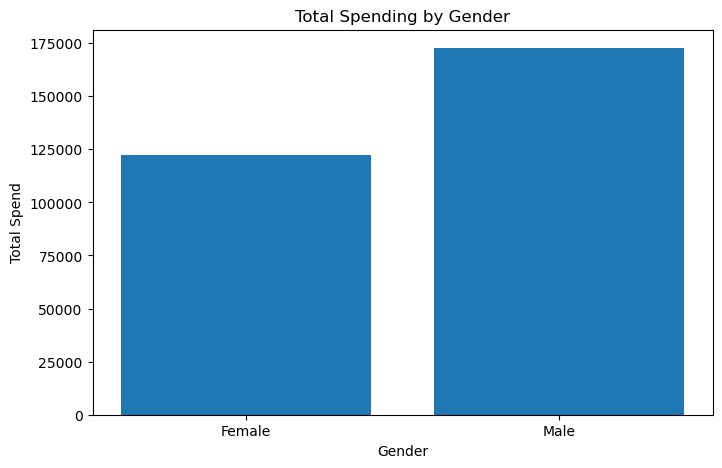

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(gender_spending['Gender'], gender_spending['Total Spend'])

plt.title('Total Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Spend')
plt.show()


In [20]:
age_spending = df.groupby('Age')['Total Spend'].sum().reset_index()
print(age_spending)

    Age  Total Spend
0    26      6205.40
1    27     17770.50
2    28     35812.40
3    29     14192.40
4    30     63631.00
5    31     28615.00
6    32     26579.90
7    33      8206.40
8    34     18985.10
9    35     20002.20
10   36     12522.80
11   37      9517.60
12   38      3998.10
13   41     11626.00
14   42      4668.45
15   43     12698.75


In [27]:
import plotly.express as px

fig = px.line(
    age_spending,
    x='Age',
    y='Total Spend',
    markers=True,
    title='Total Spend by Age'
)

fig.update_layout(
    xaxis_title='Age',
    yaxis_title='Total Spend (Currency)',
    hovermode='x unified'
)

fig.show()


C:\Users\BRIGHTMAN\AppData\Local\Temp\ipykernel_25224\1547113517.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




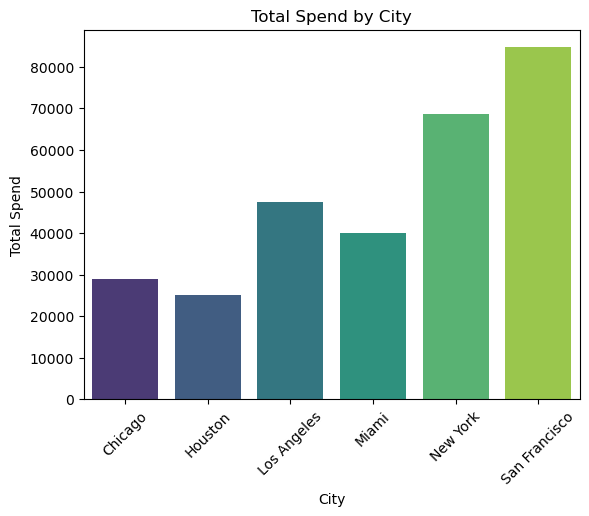

In [42]:
total_spend_by_city = df.groupby('City')['Total Spend'].sum().reset_index()
sns.barplot(data=total_spend_by_city, x='City', y='Total Spend', palette='viridis')
plt.title('Total Spend by City')
plt.xticks(rotation=45)
plt.show()

In [29]:
import plotly.express as px

membership_spend = df.groupby('Membership Type')['Total Spend'].sum().reset_index()

fig = px.bar(
    membership_spend,
    x="Membership Type",
    y="Total Spend",
    title="Total Spend by Membership Type",
    hover_data=["Total Spend"]
)

fig.show()


In [30]:
df['Membership Type'].value_counts()


Membership Type
Gold      117
Silver    117
Bronze    114
Name: count, dtype: int64

In [33]:
city_membership_counts = df.groupby(['City', 'Membership Type']).size().reset_index(name='Count')
city_membership_counts


,City,Membership Type,Count
0,Chicago,Bronze,58
1,Houston,Bronze,56
2,Los Angeles,Silver,59
3,Miami,Silver,58
4,New York,Gold,59
5,San Francisco,Gold,58


In [35]:
import plotly.express as px

fig = px.bar(
    city_membership_counts,
    x="City",
    y="Count",
    color="Membership Type",
    barmode="group",
    title="Membership Distribution by City",
    hover_data=['Membership Type', 'Count']
)

fig.show()


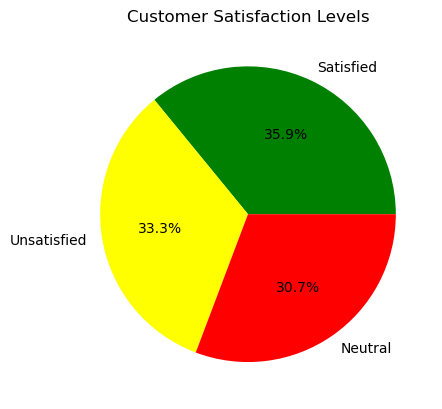

In [ ]:
# Pie chart for Satisfaction Level

df['Satisfaction Level'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green','yellow','red'])
plt.title('Customer Satisfaction Levels')
plt.ylabel('')
plt.show()


In [38]:
pip install seaborn


C:\Users\BRIGHTMAN\AppData\Local\Temp\ipykernel_25224\1659885279.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




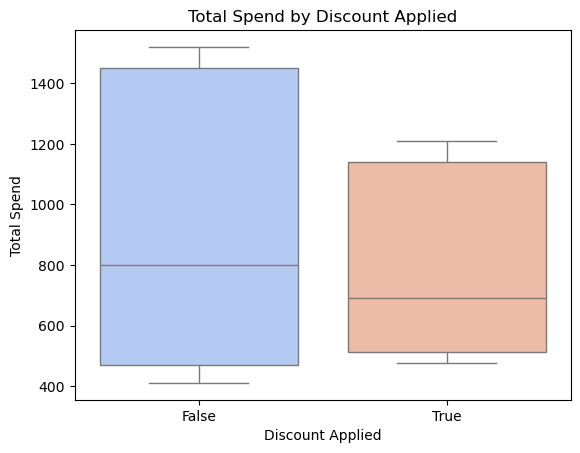

In [ ]:
# Discount Applied vs Total Spend

import seaborn as sns
sns.boxplot(data=df, x='Discount Applied', y='Total Spend', palette='coolwarm')
plt.title('Total Spend by Discount Applied')
plt.show()

C:\Users\BRIGHTMAN\AppData\Local\Temp\ipykernel_25224\1959050762.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




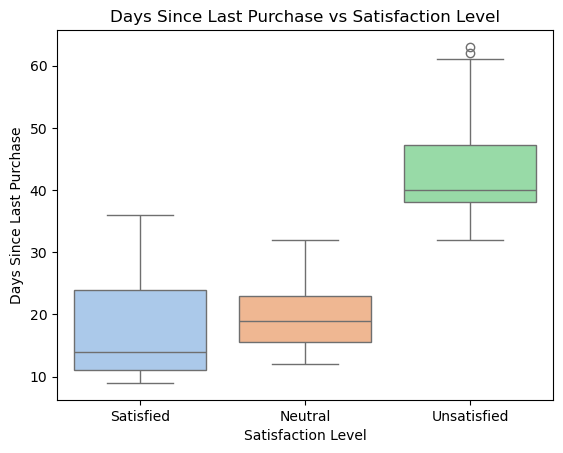

In [ ]:
# Days Since Last Purchase vs Satisfaction
sns.boxplot(data=df, x='Satisfaction Level', y='Days Since Last Purchase', palette='pastel')
plt.title('Days Since Last Purchase vs Satisfaction Level')
plt.show()

In [43]:
df.head()

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [44]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])                    # Female→0, Male→1
df['City'] = le.fit_transform(df['City'])                        # Alphabetical order
df['Discount Applied'] = df['Discount Applied'].astype(int)      # True→1, False→0 (already boolean)

# 2. Ordinal Encoding for columns that HAVE a natural order
membership_order = ['Bronze', 'Silver', 'Gold']
satisfaction_order = ['Unsatisfied', 'Neutral', 'Satisfied']

df['Membership Type'] = pd.Categorical(df['Membership Type'], 
                                        categories=membership_order, 
                                        ordered=True).codes
                                        # Bronze→0, Silver→1, Gold→2

df['Satisfaction Level'] = pd.Categorical(df['Satisfaction Level'], 
                                          categories=satisfaction_order, 
                                          ordered=True).codes
                                          # Unsatisfied→0, Neutral→1, Satisfied→2
# Check the result
print(df.head())
print("\nData types and unique values:")
print(df.dtypes)
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, df[col].unique())

   Gender  Age  City  Membership Type  Total Spend  Items Purchased  \
0       0   29     4                2      1120.20               14   
1       1   34     2                1       780.50               11   
2       0   43     0                0       510.75                9   
3       1   30     5                2      1480.30               19   
4       1   27     3                1       720.40               13   

   Average Rating  Discount Applied  Days Since Last Purchase  \
0             4.6                 1                        25   
1             4.1                 0                        18   
2             3.4                 1                        42   
3             4.7                 0                        12   
4             4.0                 1                        55   

   Satisfaction Level  
0                   2  
1                   1  
2                   0  
3                   2  
4                   0  

Data types and unique values:
Gender 

In [45]:
df.head()


,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,0,29,4,2,1120.20,14,4.6,1,25,2
1,1,34,2,1,780.50,11,4.1,0,18,1
2,0,43,0,0,510.75,9,3.4,1,42,0
3,1,30,5,2,1480.30,19,4.7,0,12,2
4,1,27,3,1,720.40,13,4.0,1,55,0


In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Separate features (drop nothing, we already encoded everything)
features = df.copy()

# Scale all numerical columns (very important for K-means!)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(features)

# Now df_scaled is a numpy array ready for K-means
# Example:
# from sklearn.cluster import KMeans
# kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
# clusters = kmeans.fit_predict(df_scaled)
# df['Cluster'] = clusters

In [49]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# 4. Find the best K with Elbow + Silhouette
from sklearn.metrics import silhouette_score


range_n_clusters = range(2, 11)
inertias = []
silhouette_avg = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(df_scaled, cluster_labels))


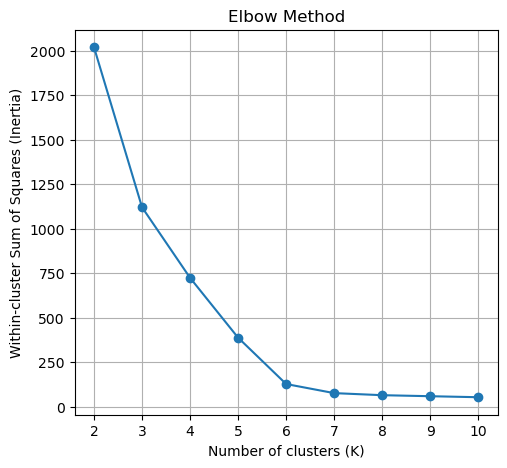

In [50]:
# Plot Elbow curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Within-cluster Sum of Squares (Inertia)')
plt.grid(True)

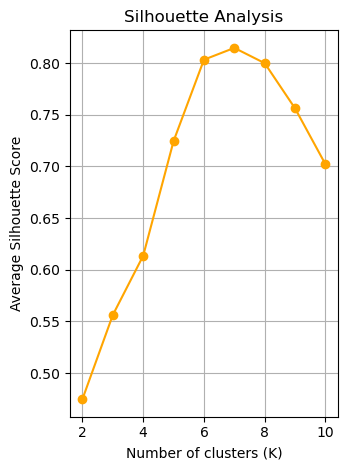

In [51]:
# Plot Silhouette scores
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_avg, marker='o', color='orange')
plt.title('Silhouette Analysis')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()


Final model uses K = 4

Cluster sizes:
Cluster
0    114
1    117
2     59
3     58
Name: count, dtype: int64

Cluster centers (in original scale):
   Gender    Age  City  Membership Type  Total Spend  Items Purchased  \
0    0.00  39.40  0.49              0.0       474.22             8.52   
1    0.50  29.92  4.50              2.0      1311.14            17.62   
2    1.00  34.12  2.00              1.0       805.49            11.68   
3    0.98  28.95  3.00              1.0       690.39            11.64   

   Average Rating  Discount Applied  Days Since Last Purchase  \
0            3.33              0.51                     31.78   
1            4.68              0.50                     17.94   
2            4.17             -0.00                     15.27   
3            3.93              1.00                     45.50   

   Satisfaction Level  Cluster  
0                0.49     -0.0  
1                2.00      1.0  
2                1.14      2.0  
3               -0.00      3

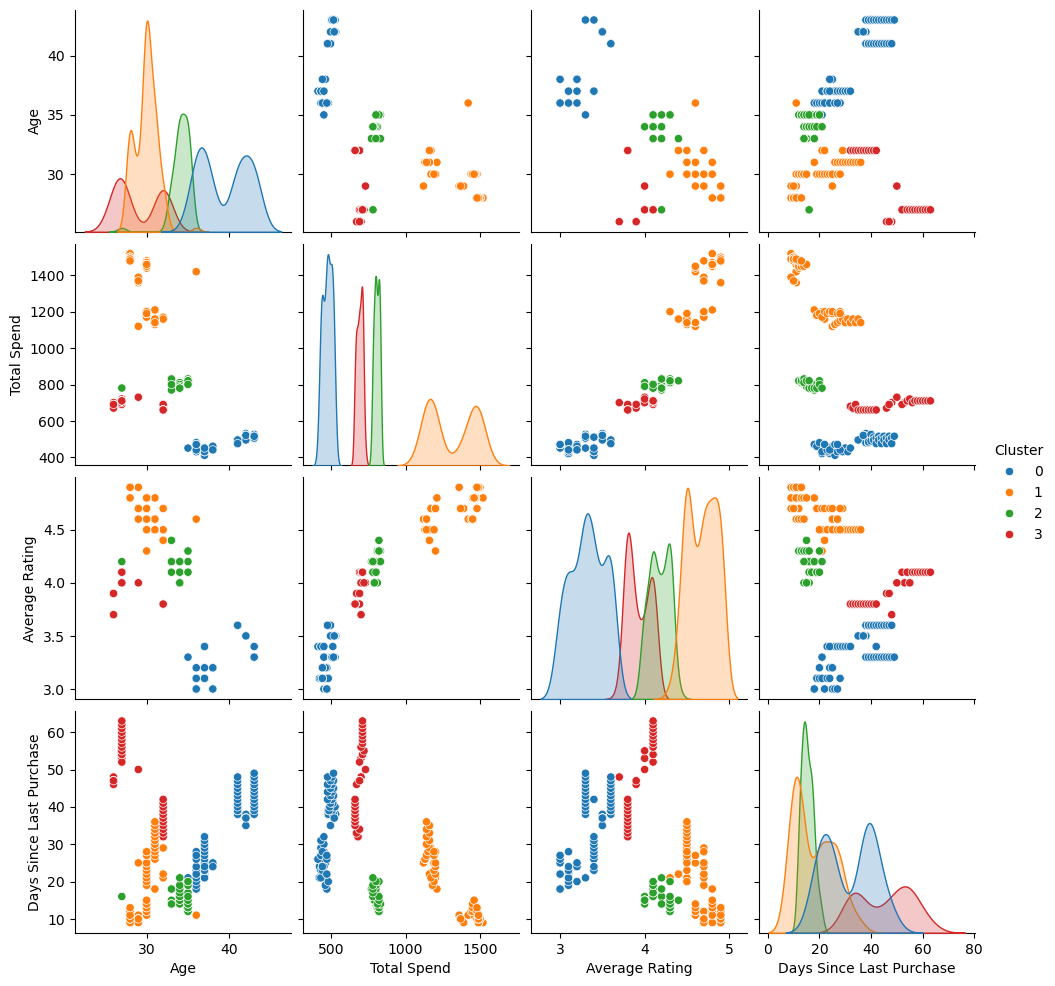

In [53]:
# 5. Choose the best K (you can change this after looking at the plots)
best_k = 4   # ← change this based on the plots (usually where elbow bends + high silhouette)

# 6. Final model with best K
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

# 7. Quick look at the results
print(f"\nFinal model uses K = {best_k}")
print("\nCluster sizes:")
print(df['Cluster'].value_counts().sort_index())

print("\nCluster centers (in original scale):")
centers_scaled = kmeans_final.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=df.columns)
print(centers_df.round(2))

# 8. Bonus: Nice pairplot to visualize clusters (optional but beautiful)
sns.pairplot(df, hue='Cluster', vars=['Age', 'Total Spend', 'Average Rating', 'Days Since Last Purchase'], 
             palette='tab10', diag_kind='kde')
plt.show()